# Nhóm 4 -  Dự đoán giá bán lại của xe máy dựa trên dữ liệu xe đã qua sử dụng

- Nguyễn Trung Hiếu  
- Đỗ Chiếm Cừ
- Trần Châu Tuấn

## 1. Giới thiệu đề tài
Thực hiện bài toán hồi quy nhằm dự đoán giá bán lại của xe máy cũ dựa trên các thông tin như tên xe, năm sản xuất, số km đã đi, loại người bán, số đời chủ và thương hiệu xe. Mục tiêu là áp dụng các mô hình học máy đã học để xây dựng mô hình có khả năng dự đoán giá xe gần với giá thực tế.




### 1.1. Tìm hiểu tổng quan về dữ liệu

Dùng tập dữ liệu `motorcycle.csv` để minh họa. Chi tiết về tập dữ liệu có thể được tham khảo ở https://www.kaggle.com/datasets/ironwolf437/laptop-price-dataset

#### 1.1.1. Load dữ liệu

In [11]:
import pandas as pd
# Đọc dữ liệu từ "motorcycle.csv"
heart = pd.read_csv('./data/motorcycle.csv')

#### 1.1.2. Thực hiện tiền xử lý dữ liệu

In [12]:
heart.head()
heart.info()
heart.describe()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   name                21 non-null     str  
 1   selling_price       21 non-null     int64
 2   year                21 non-null     int64
 3   owner               21 non-null     str  
 4   km_driven           21 non-null     int64
 5   ex_showroom_price   21 non-null     int64
 6   brand               21 non-null     str  
 7   bike_age            21 non-null     int64
 8   km_per_year         21 non-null     int64
 9   owner_encoded       21 non-null     int64
 10  selling_price_vnds  21 non-null     int64
 11  km_driven_vnds      21 non-null     int64
 12  km_per_year_vnds    21 non-null     int64
dtypes: int64(10), str(3)
memory usage: 2.3 KB


,selling_price,year,km_driven,ex_showroom_price,bike_age,km_per_year,owner_encoded,selling_price_vnds,km_driven_vnds,km_per_year_vnds
count,2.100000e+01,21.000000,21.000000,2.100000e+01,21.000000,21.000000,21.000000,2.100000e+01,21.000000,21.000000
mean,4.413710e+07,2014.904762,25525.047619,1.680436e+07,5.095238,5287.809524,1.190476,4.413710e+07,25525.047619,5287.809524
std,1.623477e+08,3.269629,17802.670346,2.960652e+07,3.269629,2540.728549,0.402374,1.623477e+08,17802.670346,2540.728549
min,1.500000e+06,2008.000000,2800.000000,4.500000e+06,1.000000,1533.000000,1.000000,1.500000e+06,2800.000000,1533.000000
25%,2.800000e+06,2012.000000,12000.000000,5.500000e+06,2.000000,3956.000000,1.000000,2.800000e+06,12000.000000,3956.000000
50%,5.000000e+06,2016.000000,21178.000000,6.160000e+06,4.000000,4600.000000,1.000000,5.000000e+06,21178.000000,4600.000000
75%,8.000000e+06,2018.000000,35600.000000,9.595500e+06,8.000000,6400.000000,1.000000,8.000000e+06,35600.000000,6400.000000
max,7.500000e+08,2019.000000,60000.000000,1.278000e+08,12.000000,10589.000000,2.000000,7.500000e+08,60000.000000,10589.000000


In [13]:
# Dọn dẹp khoảng trắng trong tên cột ngay lập tức
heart.columns = heart.columns.str.strip()

In [14]:
# 2. Loại bỏ các dòng bị trống (NaN) ở các cột quan trọng
# Dùng heart_clean để không làm hỏng dữ liệu gốc
heart_clean = heart.dropna(subset=['selling_price', 'year', 'km_driven']).copy()


In [15]:
# 3. Tạo các cột đặc trưng mới
heart_clean['brand'] = heart_clean['name'].str.split().str[0]
heart_clean['bike_age'] = 2024 - heart_clean['year']


In [16]:
# 4. Chọn biến X và y an toàn (Chỉ lấy những cột THỰC SỰ tồn tại)
# Cách này giúp tránh tuyệt đối lỗi KeyError
expected_cols = ['bike_age', 'km_driven', 'seller_type', 'owner', 'brand']
existing_cols = [c for c in expected_cols if c in heart_clean.columns]

X = heart_clean[existing_cols]
y = heart_clean['selling_price']


In [17]:
# 5. One-hot Encoding (Chuyển chữ thành số)
X_encoded = pd.get_dummies(X, drop_first=True)


In [18]:
# 6. Kiểm tra lại lần cuối trước khi chia dữ liệu
print(f"Số lượng dòng sau khi dọn dẹp: {len(heart_clean)}")
print(f"Số lượng cột sau khi Encoding: {X_encoded.shape[1]}")
print(f"Giá trị trống còn lại: {X_encoded.isnull().sum().sum()}")


Số lượng dòng sau khi dọn dẹp: 21
Số lượng cột sau khi Encoding: 10
Giá trị trống còn lại: 0


In [19]:
# 7. Chia dữ liệu Train/Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("--- ĐÃ SẴN SÀNG HUẤN LUYỆN MÔ HÌNH ---")
import pandas as pd


--- ĐÃ SẴN SÀNG HUẤN LUYỆN MÔ HÌNH ---


In [20]:
##Mô hình 1: Lasso Regression

In [21]:
# --- BƯỚC 1: DỌN DẸP TÊN CỘT ---
heart.columns = heart.columns.str.strip() # Xóa khoảng trắng thừa ở tên cột


In [22]:
# --- BƯỚC 2: TẠO CỘT MỚI ---
heart['brand'] = heart['name'].str.split().str[0]
heart['bike_age'] = 2024 - heart['year']


In [23]:
# --- BƯỚC 3: CHỌN BIẾN X VÀ Y ---
cols_to_use = ['bike_age', 'km_driven', 'seller_type', 'owner', 'brand']
X = heart[[c for c in cols_to_use if c in heart.columns]]
y = heart['selling_price']


In [24]:
# --- BƯỚC 4: ONE-HOT ENCODING ---
X_encoded = pd.get_dummies(X, drop_first=True)


In [25]:
# Kiểm tra kết quả
print(f"Số lượng cột thực tế tìm thấy: {len(X.columns)}")
print(f"Số lượng đặc trưng sau Encoding: {X_encoded.shape[1]}")
display(X_encoded.head())


Số lượng cột thực tế tìm thấy: 4
Số lượng đặc trưng sau Encoding: 10


,bike_age,km_driven,owner_2nd owner,brand_Harley-Davidson,brand_Hero,brand_Honda,brand_KTM,brand_Royal,brand_Suzuki,brand_Yamaha
0,5,5000,False,False,False,False,False,True,False,False
1,7,13650,False,False,False,True,False,False,False,False
2,6,12000,False,False,False,False,False,True,False,False
3,9,23000,False,False,False,False,False,False,False,True
4,13,37000,True,False,False,False,False,False,False,True


In [26]:
##1.	Model Selection với Lasso
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score


In [27]:
# Thử các giá trị alpha (tham số điều chỉnh độ phức tạp mô hình)
alphas = [0.01, 0.1, 1, 10, 100, 1000]

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

print(f"{'Alpha':>10} | {'Mean Train R2':>15} | {'Mean Test R2':>15}")
print("-" * 50)

for alpha in alphas:

    train_r2s = []
    test_r2s = []

    for train_index, test_index in kf.split(X_encoded):

        X_train_f = X_encoded.iloc[train_index]
        X_test_f = X_encoded.iloc[test_index]

        y_train_f = y.iloc[train_index]
        y_test_f = y.iloc[test_index]

        # Huấn luyện mô hình
        model = Lasso(alpha=alpha, max_iter=10000)
        model.fit(X_train_f, y_train_f)

        # Tính R2
        train_r2 = r2_score(y_train_f, model.predict(X_train_f))
        test_r2 = r2_score(y_test_f, model.predict(X_test_f))

        train_r2s.append(train_r2)
        test_r2s.append(test_r2)

    print(f"{alpha:10} | {np.mean(train_r2s):15.4f} | {np.mean(test_r2s):15.4f}")

     Alpha |   Mean Train R2 |    Mean Test R2
--------------------------------------------------
      0.01 |          0.9983 |        -10.7405
       0.1 |          0.9983 |        -10.7405
         1 |          0.9983 |        -10.7404
        10 |          0.9983 |        -10.7394
       100 |          0.9983 |        -10.7298
      1000 |          0.9983 |        -10.6335


In [28]:
##2.	So sánh với Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


In [29]:
# Chia dữ liệu để kiểm tra cuối cùng
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Huấn luyện Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Dự đoán
y_pred = rf.predict(X_test)

# Xuất chỉ số cho Hiếu đưa vào Report
print("--- KẾT QUẢ MÔ HÌNH RANDOM FOREST ---")
print(f"Độ phù hợp (R2 Score): {r2_score(y_test, y_pred):.4f}")
print(f"Sai số trung bình (MAE): {mean_absolute_error(y_test, y_pred):,.0f} VNĐ")


--- KẾT QUẢ MÔ HÌNH RANDOM FOREST ---
Độ phù hợp (R2 Score): -13.5088
Sai số trung bình (MAE): 16,022,074 VNĐ


In [30]:
##3.	Biểu đồ so sánh "Giá thật vs Giá dự đoán"
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
# --- BƯỚC 1: CHIA DỮ LIỆU  ---
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [32]:
# --- BƯỚC 2: HUẤN LUYỆN MÔ HÌNH  ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


In [33]:
# --- BƯỚC 3: IN KẾT QUẢ ---
print("--- KẾT QUẢ MÔ HÌNH RANDOM FOREST ---")
print(f"Độ phù hợp (R2 Score): {r2_score(y_test, y_pred):.4f}")
print(f"Sai số trung bình (MAE): {mean_absolute_error(y_test, y_pred):,.0f} VNĐ")



--- KẾT QUẢ MÔ HÌNH RANDOM FOREST ---
Độ phù hợp (R2 Score): -13.5088
Sai số trung bình (MAE): 16,022,074 VNĐ


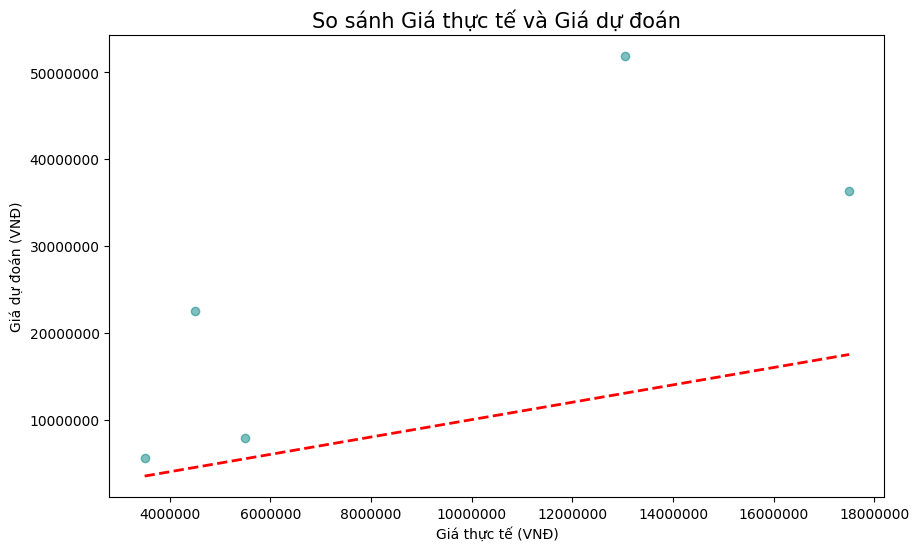

In [34]:
# --- BƯỚC 4: VẼ BIỂU ĐỒ ---
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá thực tế (VNĐ)')
plt.ylabel('Giá dự đoán (VNĐ)')
plt.title('So sánh Giá thực tế và Giá dự đoán', fontsize=15)
plt.ticklabel_format(style='plain', axis='both')
plt.show()


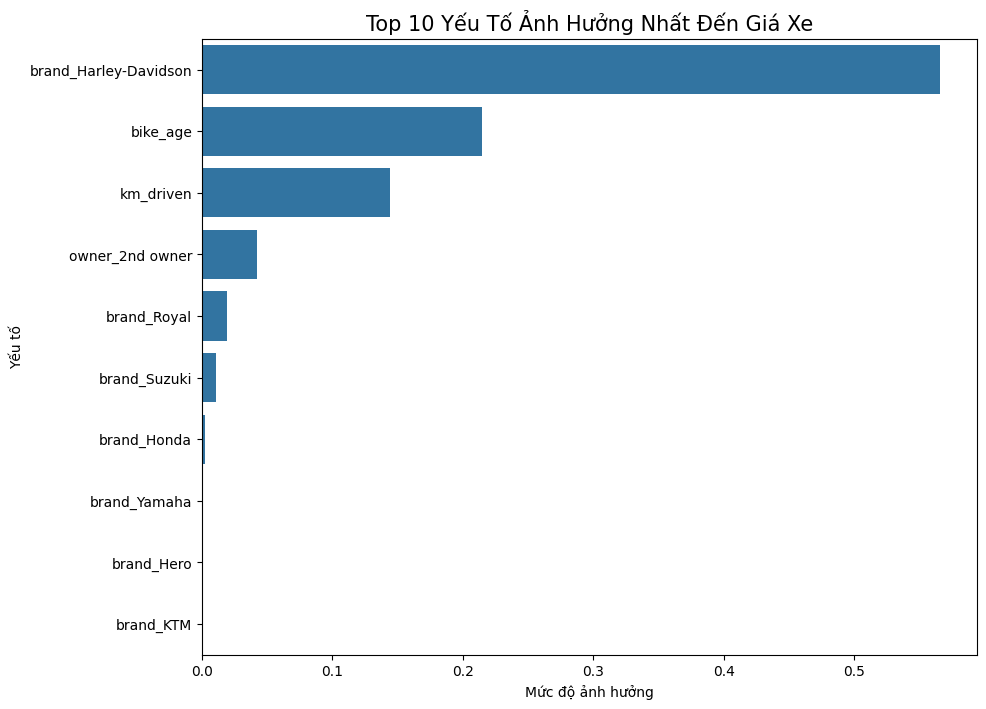

In [39]:
##4.	Biểu đồ: Yếu tố nào quyết định giá xe? (Feature Importance)
# 4. Biểu đồ: Yếu tố nào quyết định giá xe?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo bảng mức độ quan trọng của từng biến
feature_importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
})

# Lấy 10 yếu tố quan trọng nhất
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title('Top 10 Yếu Tố Ảnh Hưởng Nhất Đến Giá Xe', fontsize=15)
plt.xlabel('Mức độ ảnh hưởng')
plt.ylabel('Yếu tố')
plt.show()

In [40]:
##5.	Hàm dự đoán giá xe thực tế (Ứng dụng thực tiễn)
def predict_bike_price(bike_age, km_driven, brand, seller_type, owner):
    # Tạo một hàng dữ liệu mới với các thông số nhập vào
    sample_data = pd.DataFrame([[bike_age, km_driven, seller_type, owner, brand]], 
                                columns=['bike_age', 'km_driven', 'seller_type', 'owner', 'brand'])
    
    # Encoding mẫu dữ liệu này giống hệt tập train
    sample_encoded = pd.get_dummies(sample_data)
    sample_encoded = sample_encoded.reindex(columns=X_encoded.columns, fill_value=0)
    
    # Dự đoán
    price = rf.predict(sample_encoded)[0]
    return price


In [41]:
# --- TEST THỬ MỘT CHIẾC XE ---
# Ví dụ: Xe 3 tuổi (2021), chạy 15.000km, hãng Honda, bán bởi Cá nhân, Chủ đầu tiên
guessed_price = predict_bike_price(3, 15000, 'Honda', 'Individual', '1st owner')

print(f"Giá dự đoán cho chiếc xe của bạn là: {guessed_price:,.0f} VNĐ")


Giá dự đoán cho chiếc xe của bạn là: 29,864,710 VNĐ
